# SASRec + LightGCN Score-level Fusion Experiments

This notebook implements the full experimental pipeline for the movie recommendation project:

1. Load and preprocess MovieLens data.
2. Build a **shared chronological holdout multi-positive protocol**.
3. Train **SASRec**.
4. Train **LightGCN**.
5. Export per-user candidate scores from both models.
6. Run **score-level fusion** with alpha sweep.
7. Run **score normalization ablation**.
8. Evaluate Recall@K and NDCG@K.
9. Analyze popularity bias and long-tail recommendation behavior.

Main shared protocol:

For each user, interactions are sorted by timestamp.

- First 80% interactions → training history / training graph
- Last 20% interactions → test positives

This protocol preserves temporal order for SASRec while still allowing LightGCN to operate in a multi-positive top-K retrieval setting.

## 0. Setup

Change `DATA_PATH` below to match your dataset location.

Supported formats:

- `ratings.csv` with columns: `userId`, `movieId`, `timestamp`
- MovieLens 1M `ratings.dat` with format: `UserID::MovieID::Rating::Timestamp`

In [ ]:
import os
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

!wget -q https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -o -q ml-1m.zip


CONFIG = {
    "DATA_PATH": "ml-1m/ratings.dat",   # change to your path
    "MIN_USER_INTERACTIONS": 5,
    "TRAIN_RATIO": 0.8,
    "MAX_LEN": 50,
    "BATCH_SIZE": 512,
    "SASREC_HIDDEN_DIM": 128,
    "SASREC_NUM_HEADS": 4,
    "SASREC_NUM_LAYERS": 2,
    "SASREC_DROPOUT": 0.3,
    "SASREC_LR": 1e-3,
    "SASREC_EPOCHS": 30,
    "SASREC_WEIGHT_DECAY": 1e-5,
    "LIGHTGCN_EMB_DIM": 128,
    "LIGHTGCN_LAYERS": 4,
    "LIGHTGCN_LR": 1e-3,
    "LIGHTGCN_WEIGHT_DECAY": 1e-4,
    "LIGHTGCN_EPOCHS": 200,
    "BPR_BATCH_SIZE": 4096,
    "EVAL_KS": [10, 20],
    "CURVE_MAX_K": 30,
    "ALPHAS": [round(x, 1) for x in np.arange(0.0, 1.01, 0.1)],
}
CONFIG

Using device: cuda


{'DATA_PATH': 'ml-1m/ratings.dat',
 'MIN_USER_INTERACTIONS': 5,
 'TRAIN_RATIO': 0.8,
 'MAX_LEN': 50,
 'BATCH_SIZE': 512,
 'SASREC_HIDDEN_DIM': 128,
 'SASREC_NUM_HEADS': 4,
 'SASREC_NUM_LAYERS': 2,
 'SASREC_DROPOUT': 0.3,
 'SASREC_LR': 0.001,
 'SASREC_EPOCHS': 30,
 'SASREC_WEIGHT_DECAY': 1e-05,
 'LIGHTGCN_EMB_DIM': 128,
 'LIGHTGCN_LAYERS': 4,
 'LIGHTGCN_LR': 0.001,
 'LIGHTGCN_WEIGHT_DECAY': 0.0001,
 'LIGHTGCN_EPOCHS': 200,
 'BPR_BATCH_SIZE': 4096,
 'EVAL_KS': [10, 20],
 'CURVE_MAX_K': 30,
 'ALPHAS': [np.float64(0.0),
  np.float64(0.1),
  np.float64(0.2),
  np.float64(0.3),
  np.float64(0.4),
  np.float64(0.5),
  np.float64(0.6),
  np.float64(0.7),
  np.float64(0.8),
  np.float64(0.9),
  np.float64(1.0)]}

## 1. Load and preprocess MovieLens data

The notebook re-indexes users and movies into contiguous integer IDs.

Important convention:

- `0` is reserved for padding.
- User IDs use `0..n_users-1` for LightGCN embedding convenience.
- Item IDs use `1..n_items` because SASRec uses `0` as padding.
- LightGCN internally uses item indices `0..n_items-1`, so we convert when needed.

In [ ]:
def load_ratings(path):
    if path.endswith(".dat"):
        df = pd.read_csv(
            path,
            sep="::",
            engine="python",
            names=["userId", "movieId", "rating", "timestamp"],
        )
    else:
        df = pd.read_csv(path)

    required = {"userId", "movieId", "timestamp"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[["userId", "movieId", "timestamp"]].drop_duplicates()
    df = df.rename(columns={"userId": "raw_user", "movieId": "raw_movie"})
    return df


def reindex_ids(df):
    df = df.copy()

    user_cats = pd.Categorical(df["raw_user"])
    movie_cats = pd.Categorical(df["raw_movie"])

    df["user"] = user_cats.codes
    df["item"] = movie_cats.codes + 1

    n_users = df["user"].nunique()
    n_items = df["item"].nunique()

    user2idx = {raw: idx for idx, raw in enumerate(user_cats.categories)}
    idx2user = {idx: raw for raw, idx in user2idx.items()}

    movie2idx = {raw: idx + 1 for idx, raw in enumerate(movie_cats.categories)}
    idx2movie = {idx + 1: raw for idx, raw in enumerate(movie_cats.categories)}

    return df, n_users, n_items, user2idx, idx2user, movie2idx, idx2movie


df = load_ratings(CONFIG["DATA_PATH"])
df, n_users, n_items, user2idx, idx2user, movie2idx, idx2movie = reindex_ids(df)

print(f"Users: {n_users:,}")
print(f"Items: {n_items:,}")
print(f"Interactions: {len(df):,}")
df.head()

Users: 6,040
Items: 3,706
Interactions: 1,000,209


,raw_user,raw_movie,timestamp,user,item
0,1,1193,978300760,0,1105
1,1,661,978302109,0,640
2,1,914,978301968,0,854
3,1,3408,978300275,0,3178
4,1,2355,978824291,0,2163


## 2. Shared chronological holdout multi-positive split

This is the main protocol for direct comparison and fusion.

For each user:

- Sort by timestamp.
- Use the first 80% as train interactions.
- Use the last 20% as test positives.

Users with too few interactions are removed.

In [ ]:
def chronological_holdout_split(df, train_ratio=0.8, min_user_interactions=5):
    train_parts = []
    test_parts = []

    df = df.sort_values(["user", "timestamp"])

    for user, group in df.groupby("user"):
        group = group.sort_values("timestamp")
        n = len(group)

        if n < min_user_interactions:
            continue

        split_idx = int(n * train_ratio)

        # Need at least two train items for SASRec prefix training and at least one test item.
        if split_idx < 2 or split_idx >= n:
            continue

        train_parts.append(group.iloc[:split_idx])
        test_parts.append(group.iloc[split_idx:])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, test_df


train_df, test_df = chronological_holdout_split(
    df,
    train_ratio=CONFIG["TRAIN_RATIO"],
    min_user_interactions=CONFIG["MIN_USER_INTERACTIONS"],
)

print(f"Train interactions: {len(train_df):,}")
print(f"Test interactions: {len(test_df):,}")
print(f"Train users: {train_df['user'].nunique():,}")
print(f"Test users: {test_df['user'].nunique():,}")

Train interactions: 797,758
Test interactions: 202,451
Train users: 6,040
Test users: 6,040


In [ ]:
def build_user_sequences(df_part):
    df_part = df_part.sort_values(["user", "timestamp"])
    return df_part.groupby("user")["item"].apply(list).to_dict()


def build_user_test_sets(df_part):
    return df_part.groupby("user")["item"].apply(lambda x: set(x.tolist())).to_dict()


user_train = build_user_sequences(train_df)
user_test = build_user_test_sets(test_df)

common_users = sorted(set(user_train.keys()) & set(user_test.keys()))
user_train = {u: user_train[u] for u in common_users}
user_test = {u: user_test[u] for u in common_users}

print(f"Users used in shared evaluation: {len(common_users):,}")
print("Example user:", common_users[0])
print("Train sequence length:", len(user_train[common_users[0]]))
print("Test positives:", len(user_test[common_users[0]]))

Users used in shared evaluation: 6,040
Example user: 0
Train sequence length: 42
Test positives: 11


## 3. Evaluation metrics

Multi-positive top-K retrieval metrics:

- `Recall@K = hits in top-K / number of test positives`
- `NDCG@K = DCG@K / IDCG@K`

Training items are masked during evaluation so the model does not recommend movies the user already interacted with in the training history.

In [ ]:
def recall_ndcg_for_user(ranked_items, true_items, k):
    topk = ranked_items[:k]
    true_items = set(true_items)

    hits = [item for item in topk if item in true_items]
    recall = len(hits) / len(true_items) if len(true_items) > 0 else 0.0

    dcg = 0.0
    for rank, item in enumerate(topk):
        if item in true_items:
            dcg += 1.0 / math.log2(rank + 2)

    ideal_hits = min(len(true_items), k)
    idcg = sum(1.0 / math.log2(rank + 2) for rank in range(ideal_hits))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    return recall, ndcg


def evaluate_score_dict(score_dict, user_train, user_test, ks=(10, 20)):
    results = {f"Recall@{k}": [] for k in ks}
    results.update({f"NDCG@{k}": [] for k in ks})

    for user, scores in score_dict.items():
        if user not in user_test:
            continue

        scores = scores.copy()

        # mask padding item 0
        scores[0] = -1e9

        # mask seen training items
        for item in set(user_train[user]):
            scores[item] = -1e9

        ranked_items = np.argsort(-scores).tolist()

        for k in ks:
            recall, ndcg = recall_ndcg_for_user(ranked_items, user_test[user], k)
            results[f"Recall@{k}"].append(recall)
            results[f"NDCG@{k}"].append(ndcg)

    return {key: float(np.mean(vals)) if vals else 0.0 for key, vals in results.items()}


def evaluate_score_dict_over_k(score_dict, user_train, user_test, max_k=30):
    k_values = list(range(1, max_k + 1))
    recall_scores = []
    ndcg_scores = []

    for k in k_values:
        metrics = evaluate_score_dict(score_dict, user_train, user_test, ks=(k,))
        recall_scores.append(metrics[f"Recall@{k}"])
        ndcg_scores.append(metrics[f"NDCG@{k}"])

    return k_values, recall_scores, ndcg_scores

## 4. SASRec implementation

Important fix:

Because sequences are **left-padded**, the most recent valid item is always at the final position. Therefore, the sequence representation is:

```python
seq_repr = hidden[:, -1, :]
```

Do not use `lengths - 1` under left padding, because that is correct only for right padding.

In [ ]:
def pad_sequence(seq, max_len, pad_token=0):
    if len(seq) > max_len:
        seq = seq[-max_len:]
    if len(seq) < max_len:
        seq = [pad_token] * (max_len - len(seq)) + seq
    return seq


def build_sasrec_examples(user_train, max_len=50):
    examples = []
    for user, seq in user_train.items():
        for i in range(1, len(seq)):
            prefix = seq[:i]
            target = seq[i]
            examples.append((pad_sequence(prefix, max_len), target))
    return examples


class SASRecDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        seq, target = self.examples[idx]
        return (
            torch.tensor(seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long),
        )


def make_sasrec_dataloader(user_train, max_len, batch_size, shuffle=True):
    examples = build_sasrec_examples(user_train, max_len=max_len)
    dataset = SASRecDataset(examples)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


class SASRec(nn.Module):
    def __init__(
        self,
        num_items,
        max_len=50,
        hidden_dim=64,
        num_heads=2,
        num_layers=2,
        dropout=0.2,
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim

        self.item_embedding = nn.Embedding(
            num_embeddings=num_items + 1,
            embedding_dim=hidden_dim,
            padding_idx=0,
        )

        self.position_embedding = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=hidden_dim,
        )

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        # Optional item bias, useful for recommendation scoring.
        self.output_bias = nn.Parameter(torch.zeros(num_items + 1))

    def forward(self, input_seq):
        device = input_seq.device
        batch_size, seq_len = input_seq.shape

        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)

        item_emb = self.item_embedding(input_seq)
        pos_emb = self.position_embedding(positions)

        x = self.dropout(item_emb + pos_emb)

        padding_mask = (input_seq == 0)

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device),
            diagonal=1,
        ).bool()

        hidden = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        hidden = self.layer_norm(hidden)

        # Correct for left padding.
        seq_repr = hidden[:, -1, :]

        logits = seq_repr @ self.item_embedding.weight.T + self.output_bias
        logits = logits.clone()
        logits[:, 0] = -1e9

        return logits

## 5. Train SASRec under shared protocol

In [ ]:
def train_sasrec_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for input_seq, target in dataloader:
        input_seq = input_seq.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        logits = model(input_seq)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(dataloader), 1)


def get_sasrec_score_dict(model, user_train, max_len, device, batch_size=512):
    model.eval()
    users = list(user_train.keys())
    score_dict = {}

    with torch.no_grad():
        for start in range(0, len(users), batch_size):
            batch_users = users[start:start + batch_size]
            batch_seqs = [pad_sequence(user_train[u], max_len=max_len) for u in batch_users]
            input_tensor = torch.tensor(batch_seqs, dtype=torch.long).to(device)

            logits = model(input_tensor).detach().cpu().numpy()

            for idx, u in enumerate(batch_users):
                score_dict[u] = logits[idx]

    return score_dict


sasrec_loader = make_sasrec_dataloader(
    user_train=user_train,
    max_len=CONFIG["MAX_LEN"],
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
)

sasrec_model = SASRec(
    num_items=n_items,
    max_len=CONFIG["MAX_LEN"],
    hidden_dim=CONFIG["SASREC_HIDDEN_DIM"],
    num_heads=CONFIG["SASREC_NUM_HEADS"],
    num_layers=CONFIG["SASREC_NUM_LAYERS"],
    dropout=CONFIG["SASREC_DROPOUT"],
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
sasrec_optimizer = optim.Adam(sasrec_model.parameters(), lr=CONFIG["SASREC_LR"], weight_decay=CONFIG["SASREC_WEIGHT_DECAY"],)

sasrec_history = []

for epoch in range(1, CONFIG["SASREC_EPOCHS"] + 1):
    loss = train_sasrec_one_epoch(
        model=sasrec_model,
        dataloader=sasrec_loader,
        optimizer=sasrec_optimizer,
        criterion=criterion,
        device=DEVICE,
    )

    if epoch == 1 or epoch % 5 == 0 or epoch == CONFIG["SASREC_EPOCHS"]:
        sasrec_scores_tmp = get_sasrec_score_dict(
            sasrec_model, user_train, CONFIG["MAX_LEN"], DEVICE
        )
        metrics = evaluate_score_dict(
            sasrec_scores_tmp, user_train, user_test, ks=CONFIG["EVAL_KS"]
        )
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | {metrics}")
        sasrec_history.append({"epoch": epoch, "loss": loss, **metrics})
    else:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f}")

sasrec_scores = get_sasrec_score_dict(
    sasrec_model, user_train, CONFIG["MAX_LEN"], DEVICE
)

sasrec_metrics = evaluate_score_dict(
    sasrec_scores, user_train, user_test, ks=CONFIG["EVAL_KS"]
)

sasrec_metrics

Epoch 001 | Loss 9.7106 | {'Recall@10': 0.018957779184545057, 'Recall@20': 0.035083074641074456, 'NDCG@10': 0.08424361830319028, 'NDCG@20': 0.08000828030421624}
Epoch 002 | Loss 7.4316
Epoch 003 | Loss 6.8816
Epoch 004 | Loss 6.4479
Epoch 005 | Loss 6.1885 | {'Recall@10': 0.04596704862964626, 'Recall@20': 0.07902292437334955, 'NDCG@10': 0.1637233052355365, 'NDCG@20': 0.1509203113005754}
Epoch 006 | Loss 6.0229
Epoch 007 | Loss 5.9011
Epoch 008 | Loss 5.8088
Epoch 009 | Loss 5.7380
Epoch 010 | Loss 5.6823 | {'Recall@10': 0.051056909260105386, 'Recall@20': 0.08705125771496136, 'NDCG@10': 0.17641732131761065, 'NDCG@20': 0.16208459311897455}
Epoch 011 | Loss 5.6388
Epoch 012 | Loss 5.6029
Epoch 013 | Loss 5.5728
Epoch 014 | Loss 5.5482
Epoch 015 | Loss 5.5259 | {'Recall@10': 0.052387680401124424, 'Recall@20': 0.08884517907141497, 'NDCG@10': 0.18012443328645478, 'NDCG@20': 0.1649000000401213}
Epoch 016 | Loss 5.5055
Epoch 017 | Loss 5.4873
Epoch 018 | Loss 5.4682
Epoch 019 | Loss 5.4529
Epo

{'Recall@10': 0.05304540846591079,
 'Recall@20': 0.0902191030169289,
 'NDCG@10': 0.18381990649724902,
 'NDCG@20': 0.16775118698970423}

## 6. LightGCN implementation

LightGCN uses the training interactions only.

Important item ID convention:

- SASRec item IDs are `1..n_items`.
- LightGCN item embedding IDs are `0..n_items-1`.
- Conversion: `lightgcn_item = sasrec_item - 1`.

In [ ]:
def build_train_pairs(train_df):
    users = train_df["user"].astype(int).values
    # Convert SASRec item IDs 1..n_items to LightGCN item IDs 0..n_items-1.
    items = train_df["item"].astype(int).values - 1
    return users, items


train_users_arr, train_items_arr = build_train_pairs(train_df)

user_pos_items = defaultdict(set)
for u, i in zip(train_users_arr, train_items_arr):
    user_pos_items[int(u)].add(int(i))

print("Training pairs:", len(train_users_arr))


def build_norm_adj(n_users, n_items, users, items, device):
    """
    Build normalized bipartite adjacency matrix for LightGCN.

    Node indexing:
    users: 0..n_users-1
    items: n_users..n_users+n_items-1
    """
    num_nodes = n_users + n_items

    user_nodes = torch.tensor(users, dtype=torch.long)
    item_nodes = torch.tensor(items, dtype=torch.long) + n_users

    row = torch.cat([user_nodes, item_nodes])
    col = torch.cat([item_nodes, user_nodes])

    values = torch.ones(row.size(0), dtype=torch.float32)

    adj = torch.sparse_coo_tensor(
        indices=torch.stack([row, col], dim=0),
        values=values,
        size=(num_nodes, num_nodes),
    ).coalesce()

    deg = torch.sparse.sum(adj, dim=1).to_dense()
    deg_inv_sqrt = torch.pow(deg + 1e-12, -0.5)

    norm_values = deg_inv_sqrt[row] * values * deg_inv_sqrt[col]

    norm_adj = torch.sparse_coo_tensor(
        indices=torch.stack([row, col], dim=0),
        values=norm_values,
        size=(num_nodes, num_nodes),
    ).coalesce().to(device)

    return norm_adj


norm_adj = build_norm_adj(
    n_users=n_users,
    n_items=n_items,
    users=train_users_arr,
    items=train_items_arr,
    device=DEVICE,
)


class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=128, n_layers=4):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.emb_dim = emb_dim
        self.n_layers = n_layers

        self.user_embedding = nn.Embedding(n_users, emb_dim)
        self.item_embedding = nn.Embedding(n_items, emb_dim)

        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def propagate(self, norm_adj):
        all_emb = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        embeddings = [all_emb]

        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)
            embeddings.append(all_emb)

        final_emb = torch.stack(embeddings, dim=0).mean(dim=0)
        user_emb, item_emb = torch.split(final_emb, [self.n_users, self.n_items], dim=0)
        return user_emb, item_emb

    def forward(self, users, pos_items, neg_items, norm_adj):
        user_emb, item_emb = self.propagate(norm_adj)

        u_e = user_emb[users]
        pos_e = item_emb[pos_items]
        neg_e = item_emb[neg_items]

        pos_scores = torch.sum(u_e * pos_e, dim=1)
        neg_scores = torch.sum(u_e * neg_e, dim=1)

        return pos_scores, neg_scores, u_e, pos_e, neg_e

    def get_embeddings(self, norm_adj):
        return self.propagate(norm_adj)


def sample_bpr_batch(user_pos_items, n_items, batch_size):
    users = random.choices(list(user_pos_items.keys()), k=batch_size)
    pos_items = []
    neg_items = []

    for u in users:
        pos = random.choice(tuple(user_pos_items[u]))

        neg = random.randint(0, n_items - 1)
        while neg in user_pos_items[u]:
            neg = random.randint(0, n_items - 1)

        pos_items.append(pos)
        neg_items.append(neg)

    return (
        torch.tensor(users, dtype=torch.long),
        torch.tensor(pos_items, dtype=torch.long),
        torch.tensor(neg_items, dtype=torch.long),
    )


def bpr_loss_with_reg(pos_scores, neg_scores, u_e, pos_e, neg_e, reg_lambda=1e-4):
    bpr = -torch.mean(F.logsigmoid(pos_scores - neg_scores))

    reg = (
        u_e.pow(2).sum(dim=1)
        + pos_e.pow(2).sum(dim=1)
        + neg_e.pow(2).sum(dim=1)
    ).mean()

    loss = bpr + reg_lambda * reg
    return loss

Training pairs: 797758


## 7. Train LightGCN under shared protocol

In [ ]:
lightgcn_model = LightGCN(
    n_users=n_users,
    n_items=n_items,
    emb_dim=CONFIG["LIGHTGCN_EMB_DIM"],
    n_layers=CONFIG["LIGHTGCN_LAYERS"],
).to(DEVICE)

lightgcn_optimizer = optim.Adam(
    lightgcn_model.parameters(),
    lr=CONFIG["LIGHTGCN_LR"],
    weight_decay=0.0,
)

steps_per_epoch = max(len(train_users_arr) // CONFIG["BPR_BATCH_SIZE"], 1)
print("BPR steps per epoch:", steps_per_epoch)

lightgcn_history = []

for epoch in range(1, CONFIG["LIGHTGCN_EPOCHS"] + 1):
    lightgcn_model.train()
    total_loss = 0.0

    for _ in range(steps_per_epoch):
        users, pos_items, neg_items = sample_bpr_batch(
            user_pos_items=user_pos_items,
            n_items=n_items,
            batch_size=CONFIG["BPR_BATCH_SIZE"],
        )

        users = users.to(DEVICE)
        pos_items = pos_items.to(DEVICE)
        neg_items = neg_items.to(DEVICE)

        lightgcn_optimizer.zero_grad()
        pos_scores, neg_scores, u_e, pos_e, neg_e = lightgcn_model(
            users, pos_items, neg_items, norm_adj
        )

        loss = bpr_loss_with_reg(
            pos_scores,
            neg_scores,
            u_e,
            pos_e,
            neg_e,
            reg_lambda=CONFIG["LIGHTGCN_WEIGHT_DECAY"],
        )

        loss.backward()
        lightgcn_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch

    if epoch == 1 or epoch % 10 == 0 or epoch == CONFIG["LIGHTGCN_EPOCHS"]:
        print(f"Epoch {epoch:03d} | BPR Loss {avg_loss:.4f}")
        lightgcn_history.append({"epoch": epoch, "loss": avg_loss})
    else:
        print(f"Epoch {epoch:03d} | BPR Loss {avg_loss:.4f}")

BPR steps per epoch: 194
Epoch 001 | BPR Loss 0.4762
Epoch 002 | BPR Loss 0.3285
Epoch 003 | BPR Loss 0.3229
Epoch 004 | BPR Loss 0.3178
Epoch 005 | BPR Loss 0.3142
Epoch 006 | BPR Loss 0.3117
Epoch 007 | BPR Loss 0.3082
Epoch 008 | BPR Loss 0.3076
Epoch 009 | BPR Loss 0.3037
Epoch 010 | BPR Loss 0.3007
Epoch 011 | BPR Loss 0.2947
Epoch 012 | BPR Loss 0.2860
Epoch 013 | BPR Loss 0.2757
Epoch 014 | BPR Loss 0.2631
Epoch 015 | BPR Loss 0.2540
Epoch 016 | BPR Loss 0.2441
Epoch 017 | BPR Loss 0.2366
Epoch 018 | BPR Loss 0.2286
Epoch 019 | BPR Loss 0.2253
Epoch 020 | BPR Loss 0.2188
Epoch 021 | BPR Loss 0.2146
Epoch 022 | BPR Loss 0.2119
Epoch 023 | BPR Loss 0.2089
Epoch 024 | BPR Loss 0.2043
Epoch 025 | BPR Loss 0.2017
Epoch 026 | BPR Loss 0.1990
Epoch 027 | BPR Loss 0.1971
Epoch 028 | BPR Loss 0.1932
Epoch 029 | BPR Loss 0.1911
Epoch 030 | BPR Loss 0.1869
Epoch 031 | BPR Loss 0.1858
Epoch 032 | BPR Loss 0.1840
Epoch 033 | BPR Loss 0.1799
Epoch 034 | BPR Loss 0.1781
Epoch 035 | BPR Loss 0.

## 8. Export LightGCN scores

The returned score dictionary uses SASRec item ID convention:

- scores have length `n_items + 1`
- index `0` is padding and will be masked
- indices `1..n_items` are real movies

In [ ]:
def get_lightgcn_score_dict(model, norm_adj, users, n_items, device, batch_size=512):
    model.eval()
    score_dict = {}

    with torch.no_grad():
        user_emb, item_emb = model.get_embeddings(norm_adj)
        item_emb_t = item_emb.T

        users = list(users)

        for start in range(0, len(users), batch_size):
            batch_users = users[start:start + batch_size]
            user_tensor = torch.tensor(batch_users, dtype=torch.long, device=device)
            batch_user_emb = user_emb[user_tensor]

            # [B, n_items], LightGCN item indices are 0..n_items-1
            raw_scores = batch_user_emb @ item_emb_t
            raw_scores = raw_scores.detach().cpu().numpy()

            for idx, u in enumerate(batch_users):
                # Convert to SASRec score shape [n_items + 1]
                scores = np.full(n_items + 1, -1e9, dtype=np.float32)
                scores[1:] = raw_scores[idx]
                score_dict[u] = scores

    return score_dict


lightgcn_scores = get_lightgcn_score_dict(
    lightgcn_model,
    norm_adj,
    users=common_users,
    n_items=n_items,
    device=DEVICE,
)

lightgcn_metrics = evaluate_score_dict(
    lightgcn_scores, user_train, user_test, ks=CONFIG["EVAL_KS"]
)

lightgcn_metrics

{'Recall@10': 0.0676237145013181,
 'Recall@20': 0.12001029079669347,
 'NDCG@10': 0.13591437491668412,
 'NDCG@20': 0.14667952442530383}

## 9. Shared protocol baseline comparison

These results are directly comparable because SASRec, LightGCN, and Fusion use:

- the same users
- the same train/test split
- the same candidate item space
- the same metrics

In [ ]:
baseline_df = pd.DataFrame([
    {"Method": "SASRec-only", **sasrec_metrics},
    {"Method": "LightGCN-only", **lightgcn_metrics},
])

baseline_df

,Method,Recall@10,Recall@20,NDCG@10,NDCG@20
0,SASRec-only,0.053045,0.090219,0.183820,0.167751
1,LightGCN-only,0.067624,0.120010,0.135914,0.146680


## 10. Score normalization and fusion

In [ ]:
def clean_scores(scores):
    """Return a finite float32 copy of a score vector.

    Non-finite values are treated as masked scores.
    """
    scores = scores.copy().astype(np.float32)
    scores[~np.isfinite(scores)] = -1e9
    return scores


def normalize_scores(scores, method="zscore"):
    """Normalize a single user's score vector.

    Only valid, non-masked scores are normalized. Padding or masked items
    with score <= -1e8 are excluded from mean/std/min/max computation.
    """
    scores = clean_scores(scores)
    valid = np.isfinite(scores) & (scores > -1e8)

    if not np.any(valid):
        return scores

    if method == "none":
        return scores

    if method == "minmax":
        min_v = scores[valid].min()
        max_v = scores[valid].max()
        denom = max(max_v - min_v, 1e-8)
        scores[valid] = (scores[valid] - min_v) / denom
        return scores

    if method == "zscore":
        mean_v = scores[valid].mean()
        std_v = scores[valid].std()
        std_v = max(std_v, 1e-8)
        scores[valid] = (scores[valid] - mean_v) / std_v
        return scores

    raise ValueError(f"Unknown normalization method: {method}")


def fuse_score_dicts(sasrec_scores, lightgcn_scores, alpha=0.5, norm_method="zscore"):
    """Fuse SASRec and LightGCN score dictionaries by fixed alpha.

    alpha=0.0 returns the LightGCN endpoint.
    alpha=1.0 returns the SASRec endpoint.

    Endpoint branches are intentionally explicit to avoid numerical issues like
    0 * NaN or 0 * inf contaminating the fused score vector.
    """
    fused = {}
    common = sorted(set(sasrec_scores.keys()) & set(lightgcn_scores.keys()))

    for u in common:
        if sasrec_scores[u].shape != lightgcn_scores[u].shape:
            raise ValueError(
                f"Score shape mismatch for user {u}: "
                f"SASRec {sasrec_scores[u].shape}, "
                f"LightGCN {lightgcn_scores[u].shape}"
            )

        s1 = normalize_scores(sasrec_scores[u], method=norm_method)
        s2 = normalize_scores(lightgcn_scores[u], method=norm_method)

        if alpha == 0.0:
            fused_scores = s2.copy()
        elif alpha == 1.0:
            fused_scores = s1.copy()
        else:
            fused_scores = alpha * s1 + (1.0 - alpha) * s2

        fused_scores[~np.isfinite(fused_scores)] = -1e9
        fused_scores[0] = -1e9
        fused[u] = fused_scores

    return fused

In [ ]:
def run_alpha_sweep(
    sasrec_scores,
    lightgcn_scores,
    user_train,
    user_test,
    norm_method="none",
    alphas=None,
    ks=None,
):
    if alphas is None:
        alphas = np.arange(0.0, 1.01, 0.1)

    if ks is None:
        ks = CONFIG["EVAL_KS"]

    results = []

    for alpha in alphas:
        alpha = round(float(alpha), 1)

        fused_scores = fuse_score_dicts(
            sasrec_scores=sasrec_scores,
            lightgcn_scores=lightgcn_scores,
            alpha=alpha,
            norm_method=norm_method,
        )

        metrics = evaluate_score_dict(
            fused_scores,
            user_train,
            user_test,
            ks=ks,
        )

        results.append({
            "Normalization": norm_method,
            "alpha": alpha,
            **metrics,
        })

    return pd.DataFrame(results)

In [ ]:
alpha_df_none = run_alpha_sweep(
    sasrec_scores=sasrec_scores,
    lightgcn_scores=lightgcn_scores,
    user_train=user_train,
    user_test=user_test,
    norm_method="none",
)

alpha_df_minmax = run_alpha_sweep(
    sasrec_scores=sasrec_scores,
    lightgcn_scores=lightgcn_scores,
    user_train=user_train,
    user_test=user_test,
    norm_method="minmax",
)

alpha_df_zscore = run_alpha_sweep(
    sasrec_scores=sasrec_scores,
    lightgcn_scores=lightgcn_scores,
    user_train=user_train,
    user_test=user_test,
    norm_method="zscore",
)

In [ ]:
print("Raw score fusion: norm=none")
display(alpha_df_none)

print("Min-max normalized fusion")
display(alpha_df_minmax)

print("Z-score normalized fusion")
display(alpha_df_zscore)

Raw score fusion: norm=none


,Normalization,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,none,0.0,0.067624,0.120010,0.135914,0.146680
1,none,0.1,0.041532,0.078315,0.123096,0.124182
2,none,0.2,0.046077,0.077253,0.146069,0.140041
3,none,0.3,0.045767,0.081102,0.160722,0.152286
4,none,0.4,0.051853,0.090285,0.179969,0.168504
5,none,0.5,0.055251,0.095116,0.191097,0.176877
6,none,0.6,0.056842,0.097187,0.196759,0.181022
7,none,0.7,0.057333,0.097574,0.198696,0.181919
8,none,0.8,0.057137,0.096542,0.197512,0.179766
9,none,0.9,0.055822,0.094578,0.192444,0.175433


Min-max normalized fusion


,Normalization,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,minmax,0.0,0.067624,0.120010,0.135914,0.146680
1,minmax,0.1,0.031170,0.057896,0.115147,0.111120
2,minmax,0.2,0.039863,0.072030,0.142440,0.135798
3,minmax,0.3,0.048133,0.084769,0.168009,0.158508
4,minmax,0.4,0.053453,0.092925,0.185315,0.173082
5,minmax,0.5,0.056174,0.096233,0.193576,0.178824
6,minmax,0.6,0.057193,0.097331,0.197674,0.181284
7,minmax,0.7,0.057218,0.096904,0.197811,0.180407
8,minmax,0.8,0.056649,0.096039,0.195600,0.178313
9,minmax,0.9,0.055621,0.094130,0.191377,0.174384


Z-score normalized fusion


,Normalization,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,zscore,0.0,0.067624,0.120010,0.135914,0.146680
1,zscore,0.1,0.032721,0.059660,0.118536,0.113892
2,zscore,0.2,0.041464,0.074609,0.147090,0.140006
3,zscore,0.3,0.049528,0.086696,0.171991,0.161920
4,zscore,0.4,0.054103,0.093166,0.186650,0.173331
5,zscore,0.5,0.056089,0.096180,0.193454,0.178466
6,zscore,0.6,0.057047,0.097171,0.197133,0.180772
7,zscore,0.7,0.057124,0.096658,0.197304,0.179864
8,zscore,0.8,0.056600,0.095849,0.195185,0.177908
9,zscore,0.9,0.055515,0.094000,0.190838,0.173967


In [ ]:
def plot_alpha_sensitivity(alpha_df, title_prefix="Alpha Sensitivity"):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Recall plot
    axes[0].plot(
        alpha_df["alpha"],
        alpha_df["Recall@10"],
        marker="o",
        label="Recall@10",
    )
    axes[0].plot(
        alpha_df["alpha"],
        alpha_df["Recall@20"],
        marker="o",
        label="Recall@20",
    )
    axes[0].set_title(f"{title_prefix}: Recall")
    axes[0].set_ylabel("Recall")
    axes[0].grid(True)
    axes[0].legend()

    # NDCG plot
    axes[1].plot(
        alpha_df["alpha"],
        alpha_df["NDCG@10"],
        marker="s",
        label="NDCG@10",
    )
    axes[1].plot(
        alpha_df["alpha"],
        alpha_df["NDCG@20"],
        marker="s",
        label="NDCG@20",
    )
    axes[1].set_title(f"{title_prefix}: NDCG")
    axes[1].set_xlabel("Alpha")
    axes[1].set_ylabel("NDCG")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

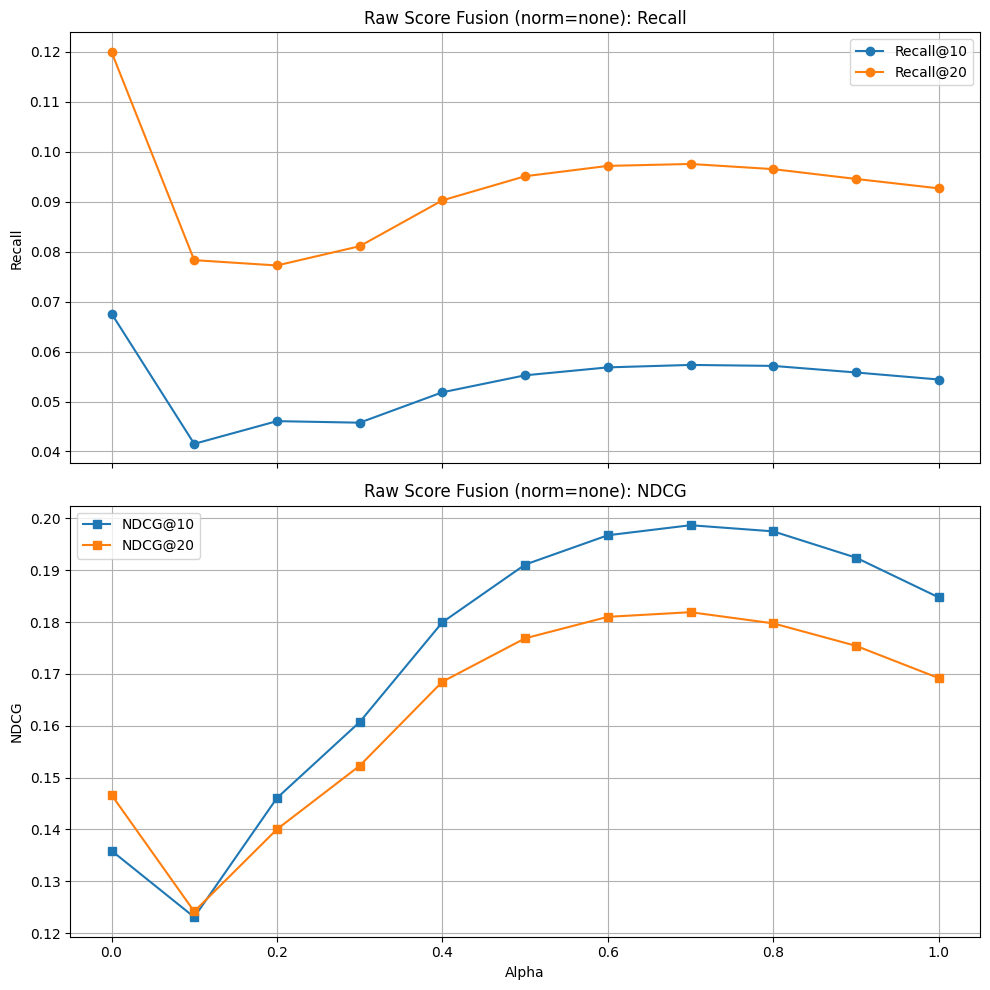

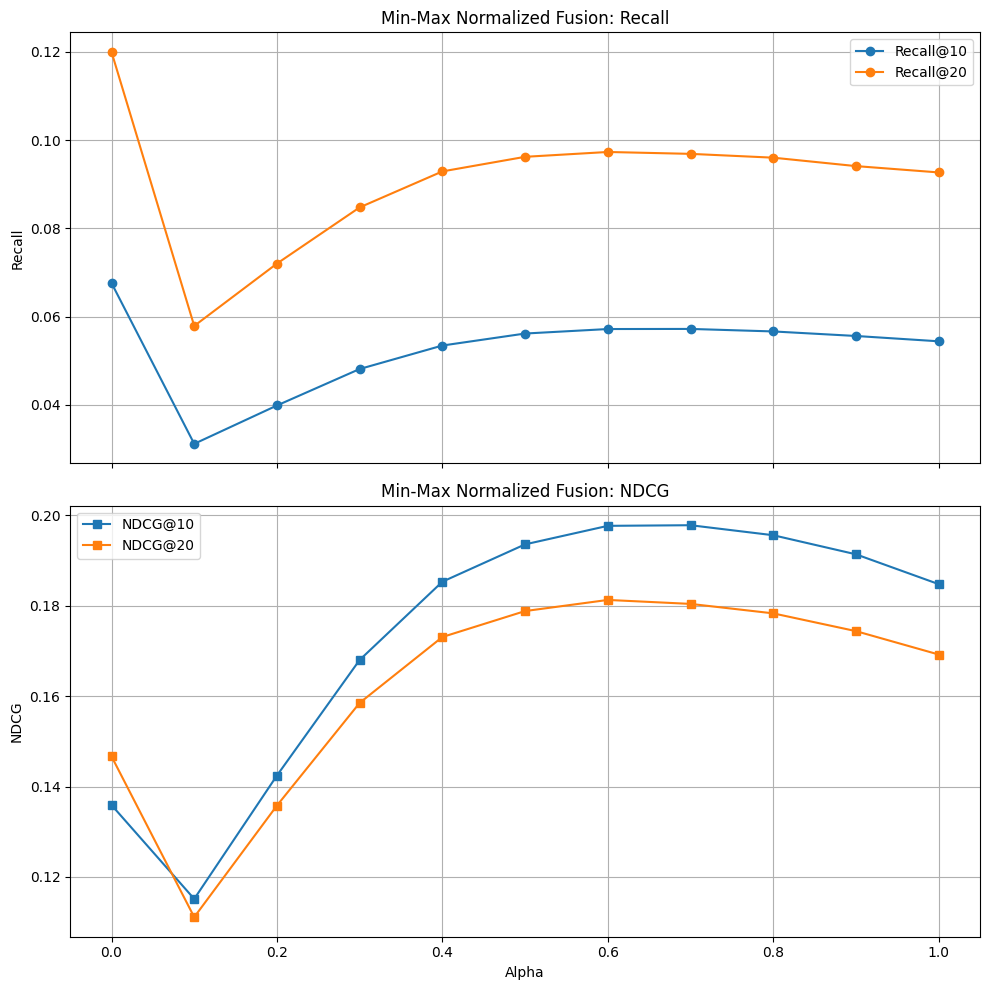

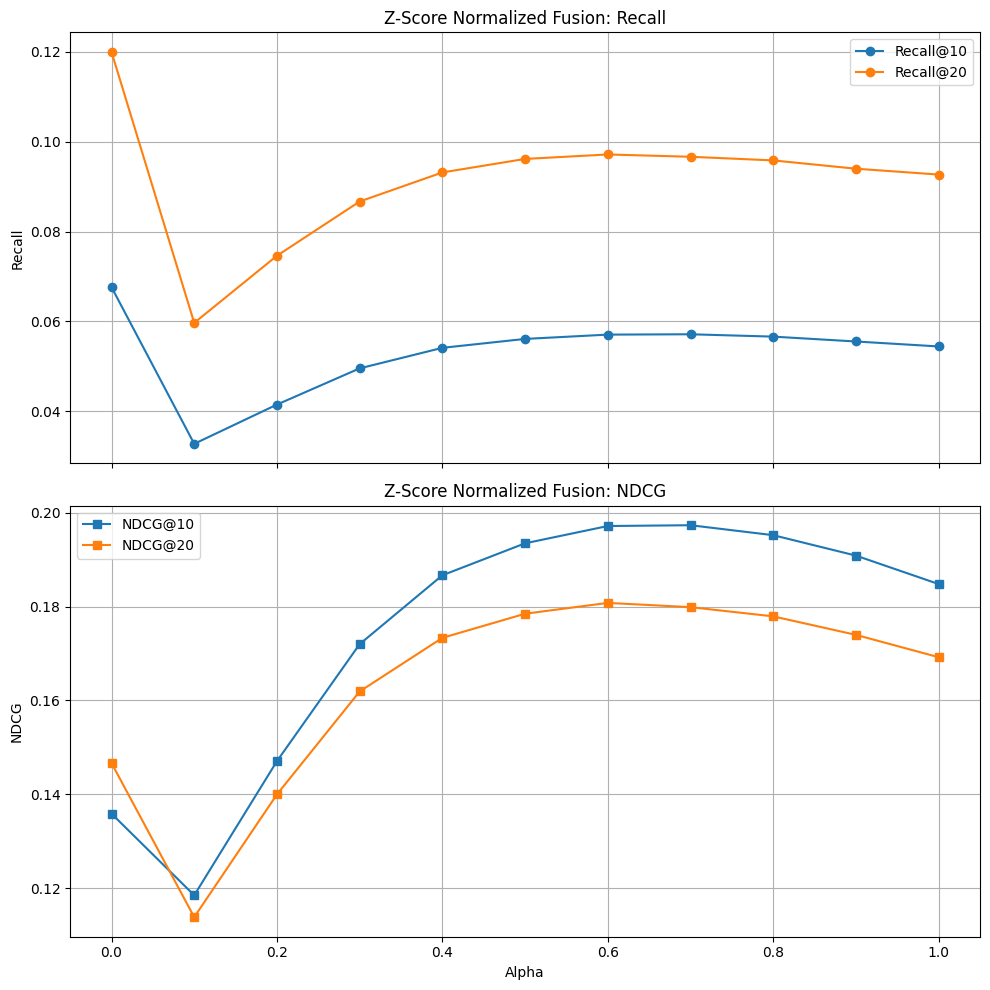

In [ ]:
plot_alpha_sensitivity(
    alpha_df_none,
    title_prefix="Raw Score Fusion (norm=none)"
)

plot_alpha_sensitivity(
    alpha_df_minmax,
    title_prefix="Min-Max Normalized Fusion"
)

plot_alpha_sensitivity(
    alpha_df_zscore,
    title_prefix="Z-Score Normalized Fusion"
)

In [ ]:
def summarize_best_by_ndcg10(alpha_dfs):
    summary_rows = []

    for norm_name, df in alpha_dfs.items():
        best_idx = df["NDCG@10"].idxmax()
        best_row = df.loc[best_idx].copy()

        summary_rows.append({
            "Normalization": norm_name,
            "Best alpha": best_row["alpha"],
            "Recall@10": best_row["Recall@10"],
            "Recall@20": best_row["Recall@20"],
            "NDCG@10": best_row["NDCG@10"],
            "NDCG@20": best_row["NDCG@20"],
        })

    return pd.DataFrame(summary_rows)


norm_ablation_summary = summarize_best_by_ndcg10({
    "none": alpha_df_none,
    "minmax": alpha_df_minmax,
    "zscore": alpha_df_zscore,
})

norm_ablation_summary

,Normalization,Best alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,none,0.7,0.057333,0.097574,0.198696,0.181919
1,minmax,0.7,0.057218,0.096904,0.197811,0.180407
2,zscore,0.7,0.057124,0.096658,0.197304,0.179864


## 11. Final clean fusion setting

This section replaces the older experimental cells. It avoids stale-variable problems by recomputing all final results from the current `sasrec_scores` and `lightgcn_scores` dictionaries.

Main reporting choice:

- Main normalization: `zscore`
- Best alpha selected by `NDCG@10`
- Final tables use only variables with the `*_clean` or `main_*` naming convention.

In [ ]:
# =========================
# Final clean recomputation
# =========================

main_norm = "zscore"
main_alpha_df = alpha_df_zscore.copy()

# Recompute baselines directly from the current score dictionaries.
sasrec_metrics_clean = evaluate_score_dict(
    sasrec_scores,
    user_train,
    user_test,
    ks=CONFIG["EVAL_KS"],
)

lightgcn_metrics_clean = evaluate_score_dict(
    lightgcn_scores,
    user_train,
    user_test,
    ks=CONFIG["EVAL_KS"],
)

# Select the best alpha under the main normalization using NDCG@10.
main_best_idx = main_alpha_df["NDCG@10"].idxmax()
main_best_row = main_alpha_df.loc[main_best_idx]
main_best_alpha = float(main_best_row["alpha"])

main_fusion_scores = fuse_score_dicts(
    sasrec_scores=sasrec_scores,
    lightgcn_scores=lightgcn_scores,
    alpha=main_best_alpha,
    norm_method=main_norm,
)

main_fusion_metrics = evaluate_score_dict(
    main_fusion_scores,
    user_train,
    user_test,
    ks=CONFIG["EVAL_KS"],
)

print("Clean SASRec-only:")
print(sasrec_metrics_clean)
print("Clean LightGCN-only:")
print(lightgcn_metrics_clean)
print(f"Main norm: {main_norm}")
print(f"Best alpha selected by NDCG@10: {main_best_alpha}")
print("Main fusion metrics:")
print(main_fusion_metrics)

final_comparison_clean = pd.DataFrame([
    {"Method": "SASRec-only", **sasrec_metrics_clean},
    {"Method": "LightGCN-only", **lightgcn_metrics_clean},
    {"Method": f"Best Fusion ({main_norm}, alpha={main_best_alpha})", **main_fusion_metrics},
])

final_comparison_clean

Clean SASRec-only:
{'Recall@10': 0.05304540846591079, 'Recall@20': 0.0902191030169289, 'NDCG@10': 0.18381990649724902, 'NDCG@20': 0.16775118698970423}
Clean LightGCN-only:
{'Recall@10': 0.0676237145013181, 'Recall@20': 0.12001029079669347, 'NDCG@10': 0.13591437491668412, 'NDCG@20': 0.14667952442530383}
Main norm: zscore
Best alpha selected by NDCG@10: 0.7
Main fusion metrics:
{'Recall@10': 0.05712364549008743, 'Recall@20': 0.09665808037651821, 'NDCG@10': 0.19730410162648562, 'NDCG@20': 0.1798638159833584}


,Method,Recall@10,Recall@20,NDCG@10,NDCG@20
0,SASRec-only,0.053045,0.090219,0.183820,0.167751
1,LightGCN-only,0.067624,0.120010,0.135914,0.146680
2,"Best Fusion (zscore, alpha=0.7)",0.057124,0.096658,0.197304,0.179864


## 12. Endpoint sanity check

For fixed fusion, endpoints must reproduce the single-model results:

- `alpha=0.0` should match LightGCN-only.
- `alpha=1.0` should match SASRec-only.

This check is included to catch score-dictionary, masking, item-ID, or stale-variable problems.

In [ ]:
def endpoint_sanity_check(norm_method="zscore"):
    alpha0_scores = fuse_score_dicts(
        sasrec_scores=sasrec_scores,
        lightgcn_scores=lightgcn_scores,
        alpha=0.0,
        norm_method=norm_method,
    )

    alpha1_scores = fuse_score_dicts(
        sasrec_scores=sasrec_scores,
        lightgcn_scores=lightgcn_scores,
        alpha=1.0,
        norm_method=norm_method,
    )

    alpha0_metrics = evaluate_score_dict(
        alpha0_scores,
        user_train,
        user_test,
        ks=CONFIG["EVAL_KS"],
    )

    alpha1_metrics = evaluate_score_dict(
        alpha1_scores,
        user_train,
        user_test,
        ks=CONFIG["EVAL_KS"],
    )

    print(f"===== Endpoint sanity check: norm={norm_method} =====")
    print("alpha=0.0 fusion:")
    print(alpha0_metrics)
    print("LightGCN-only clean baseline:")
    print(lightgcn_metrics_clean)

    print("alpha=1.0 fusion:")
    print(alpha1_metrics)
    print("SASRec-only clean baseline:")
    print(sasrec_metrics_clean)

    return alpha0_metrics, alpha1_metrics


endpoint_none = endpoint_sanity_check(norm_method="none")
endpoint_zscore = endpoint_sanity_check(norm_method=main_norm)

===== Endpoint sanity check: norm=none =====
alpha=0.0 fusion:
{'Recall@10': 0.0676237145013181, 'Recall@20': 0.12001029079669347, 'NDCG@10': 0.13591437491668412, 'NDCG@20': 0.14667952442530383}
LightGCN-only clean baseline:
{'Recall@10': 0.0676237145013181, 'Recall@20': 0.12001029079669347, 'NDCG@10': 0.13591437491668412, 'NDCG@20': 0.14667952442530383}
alpha=1.0 fusion:
{'Recall@10': 0.05441441611389195, 'Recall@20': 0.09269575164423977, 'NDCG@10': 0.18478200129231748, 'NDCG@20': 0.16921339214124897}
SASRec-only clean baseline:
{'Recall@10': 0.05304540846591079, 'Recall@20': 0.0902191030169289, 'NDCG@10': 0.18381990649724902, 'NDCG@20': 0.16775118698970423}
===== Endpoint sanity check: norm=zscore =====
alpha=0.0 fusion:
{'Recall@10': 0.0676237145013181, 'Recall@20': 0.12001029079669347, 'NDCG@10': 0.13591437491668412, 'NDCG@20': 0.14667952442530383}
LightGCN-only clean baseline:
{'Recall@10': 0.0676237145013181, 'Recall@20': 0.12001029079669347, 'NDCG@10': 0.13591437491668412, 'NDCG

## 13. Popularity and long-tail analysis

This section uses `main_fusion_scores`, not any old `best_fusion_scores` variable.

In [ ]:
def item_popularity_from_train(train_df, n_items):
    pop = np.zeros(n_items + 1, dtype=np.int64)
    counts = train_df["item"].value_counts()
    for item, cnt in counts.items():
        pop[int(item)] = int(cnt)
    return pop


def head_tail_split(item_pop, head_ratio=0.2):
    real_items = np.arange(1, len(item_pop))
    sorted_items = sorted(real_items, key=lambda x: item_pop[x], reverse=True)
    head_cutoff = int(len(sorted_items) * head_ratio)
    head_items = set(sorted_items[:head_cutoff])
    tail_items = set(sorted_items[head_cutoff:])
    return head_items, tail_items


def get_topk_recommendations(score_dict, user_train, k=10):
    recs = {}

    for u, scores in score_dict.items():
        scores = scores.copy()
        scores[0] = -1e9

        for item in set(user_train[u]):
            scores[item] = -1e9

        topk = np.argsort(-scores)[:k].tolist()
        recs[u] = topk

    return recs


def popularity_metrics(score_dict, user_train, item_pop, tail_items, k=10):
    recs = get_topk_recommendations(score_dict, user_train, k=k)

    all_rec_items = []
    avg_pop_by_user = []
    tail_ratio_by_user = []

    for u, items in recs.items():
        all_rec_items.extend(items)
        avg_pop_by_user.append(float(np.mean([item_pop[i] for i in items])))
        tail_ratio_by_user.append(float(np.mean([1.0 if i in tail_items else 0.0 for i in items])))

    item_coverage = len(set(all_rec_items)) / (len(item_pop) - 1)

    return {
        f"AvgPop@{k}": float(np.mean(avg_pop_by_user)),
        f"LongTailRatio@{k}": float(np.mean(tail_ratio_by_user)),
        f"ItemCoverage@{k}": float(item_coverage),
    }


item_pop = item_popularity_from_train(train_df, n_items)
head_items, tail_items = head_tail_split(item_pop, head_ratio=0.2)

print(f"Head items: {len(head_items):,}")
print(f"Tail items: {len(tail_items):,}")

pop_rows = []
for name, scores in [
    ("SASRec-only", sasrec_scores),
    ("LightGCN-only", lightgcn_scores),
    (f"Best Fusion ({main_norm}, alpha={main_best_alpha})", main_fusion_scores),
]:
    pop_metrics = popularity_metrics(
        score_dict=scores,
        user_train=user_train,
        item_pop=item_pop,
        tail_items=tail_items,
        k=10,
    )
    pop_rows.append({"Method": name, **pop_metrics})

pop_df_clean = pd.DataFrame(pop_rows)
pop_df_clean

Head items: 741
Tail items: 2,965


,Method,AvgPop@10,LongTailRatio@10,ItemCoverage@10
0,SASRec-only,723.996623,0.263858,0.719644
1,LightGCN-only,1134.984702,0.098394,0.482191
2,"Best Fusion (zscore, alpha=0.7)",526.959288,0.429768,0.544792


## 14. Optional K=1..30 curves

These curves also use the clean main fusion scores.

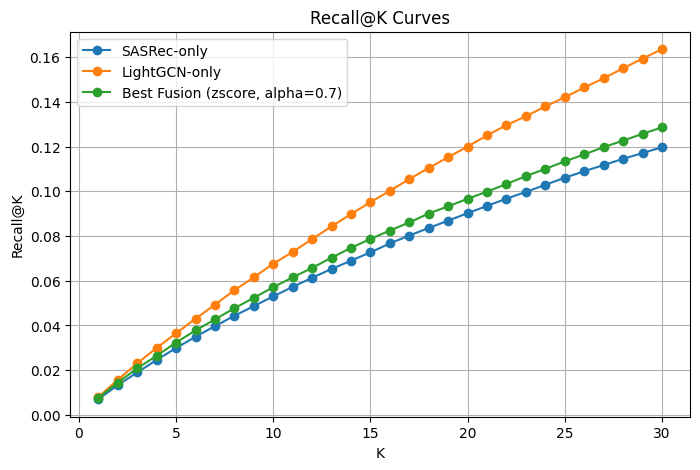

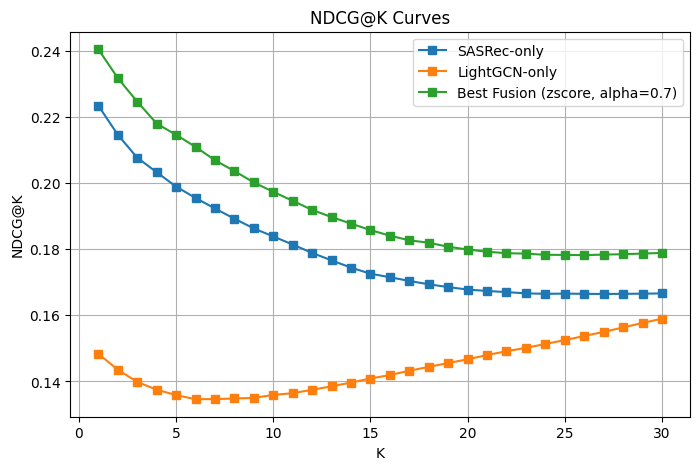

In [ ]:
def plot_k_curves(score_dicts, user_train, user_test, max_k=30):
    plt.figure(figsize=(8, 5))
    for name, scores in score_dicts.items():
        k_values, recalls, ndcgs = evaluate_score_dict_over_k(
            scores, user_train, user_test, max_k=max_k
        )
        plt.plot(k_values, recalls, marker="o", label=name)
    plt.xlabel("K")
    plt.ylabel("Recall@K")
    plt.title("Recall@K Curves")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    for name, scores in score_dicts.items():
        k_values, recalls, ndcgs = evaluate_score_dict_over_k(
            scores, user_train, user_test, max_k=max_k
        )
        plt.plot(k_values, ndcgs, marker="s", label=name)
    plt.xlabel("K")
    plt.ylabel("NDCG@K")
    plt.title("NDCG@K Curves")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_k_curves(
    {
        "SASRec-only": sasrec_scores,
        "LightGCN-only": lightgcn_scores,
        f"Best Fusion ({main_norm}, alpha={main_best_alpha})": main_fusion_scores,
    },
    user_train=user_train,
    user_test=user_test,
    max_k=CONFIG["CURVE_MAX_K"],
)

## 15. Final clean summary

Use these tables in the report. Do not use old variables such as `alpha_df`, `norm_df`, `best_fusion_scores`, `best_fusion_metrics`, `shared_summary_df`, or `pop_df`.

In [ ]:
print("Shared Protocol Comparison")
display(final_comparison_clean)

print("Alpha Sensitivity: main z-score fusion")
display(main_alpha_df)

print("Normalization Ablation")
display(norm_ablation_summary)

print("Popularity / Long-tail Analysis")
display(pop_df_clean)

Shared Protocol Comparison


,Method,Recall@10,Recall@20,NDCG@10,NDCG@20
0,SASRec-only,0.053045,0.090219,0.183820,0.167751
1,LightGCN-only,0.067624,0.120010,0.135914,0.146680
2,"Best Fusion (zscore, alpha=0.7)",0.057124,0.096658,0.197304,0.179864


Alpha Sensitivity: main z-score fusion


,Normalization,alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,zscore,0.0,0.067624,0.120010,0.135914,0.146680
1,zscore,0.1,0.032721,0.059660,0.118536,0.113892
2,zscore,0.2,0.041464,0.074609,0.147090,0.140006
3,zscore,0.3,0.049528,0.086696,0.171991,0.161920
4,zscore,0.4,0.054103,0.093166,0.186650,0.173331
5,zscore,0.5,0.056089,0.096180,0.193454,0.178466
6,zscore,0.6,0.057047,0.097171,0.197133,0.180772
7,zscore,0.7,0.057124,0.096658,0.197304,0.179864
8,zscore,0.8,0.056600,0.095849,0.195185,0.177908
9,zscore,0.9,0.055515,0.094000,0.190838,0.173967


Normalization Ablation


,Normalization,Best alpha,Recall@10,Recall@20,NDCG@10,NDCG@20
0,none,0.7,0.057333,0.097574,0.198696,0.181919
1,minmax,0.7,0.057218,0.096904,0.197811,0.180407
2,zscore,0.7,0.057124,0.096658,0.197304,0.179864


Popularity / Long-tail Analysis


,Method,AvgPop@10,LongTailRatio@10,ItemCoverage@10
0,SASRec-only,723.996623,0.263858,0.719644
1,LightGCN-only,1134.984702,0.098394,0.482191
2,"Best Fusion (zscore, alpha=0.7)",526.959288,0.429768,0.544792
